# Meko (esempio di problema di allocazione ottima di risorse)

## La Meko è una multinazionale specializzata nella produzione di biocarburanti.
Presso lo stabilimento di Oaxaca (Messico) si realizzano due prodotti, il **biometanolo** e il **biodimetiletere**. 
Il processo produttivo richiede la lavorazione nei tre stabilimenti di **preparazione**, **purificazione** ed **estrazione**. I tempi necessari per la lavorazione di una tonnellata dei due biocarburanti sono riportati in tabella, unitamente alla capacità produttiva giornaliera dei tre stabilimenti.


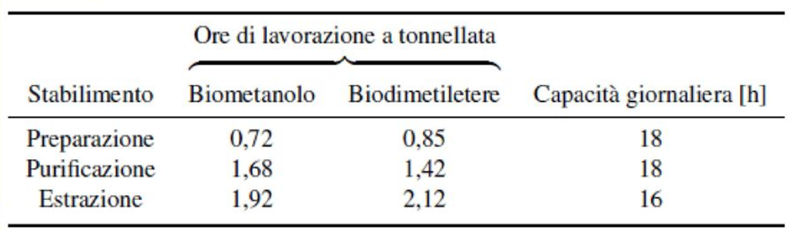

Il responsabile del marketing aziendale ha confermato che ogni tonnellata prodotta di **biometanolo** e di **biodimetiletere** può essere venduta, realizzando un profitto (in €) pari a **540** e **590**, rispettivamente.


# Formulazione del problema

### Variabili

$x_{j}, \ j =1,2 $: livello di produzione giornaliera dei due carburanti (1 - biometanolo; 2 - biodimetiletere).


## Importa la libreria GRB inizializza il problema e definisce le variabili

In [1]:
import gurobipy as gp
from gurobipy import GRB

import numpy as np

# Inizializza il modelo
mod = gp.Model('Meko')

# Crea le varibili di decisione

prod = range(2)
res = range(3)
xvar = mod.addVars(prod, name="X")

Set parameter Username
Academic license - for non-commercial use only - expires 2023-07-14


In [2]:
xvar

{0: <gurobi.Var *Awaiting Model Update*>,
 1: <gurobi.Var *Awaiting Model Update*>}

### Objective Function

- Massimizza il profitto

\begin{equation}
\text{Maximize} \quad 540 \ x_1 + 590 \ x_2 
\end{equation}

In [3]:
objcoeff =[540, 590]
obj = mod.setObjective(xvar.prod(objcoeff), GRB.MAXIMIZE)

### Vincoli del problema

- Reparto preparazione

\begin{equation}
0.72 \ x_1 + 0.85 \ x2 \leq 18
\end{equation}

- Reparto purificazione

\begin{equation}
1.68 \ x_1 + 1.42 \ x2 \leq 18
\end{equation}

- Reparto estrazione

\begin{equation}
1.92 \ x_1 + 2.12 \ x2 \leq 16
\end{equation}


In [4]:

MatTassiDiAss = [ [0.72, 0.85], [1.68, 1.42], [1.92, 2.12] ]
Cap = [18, 18, 16]

Constrs = mod.addConstrs((xvar.prod(MatTassiDiAss[i]) <= Cap[i] for i in res), "Resource")
              



# Soluzione del problema

### Risolve il problema

In [5]:
mod.optimize()

Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 3 rows, 2 columns and 6 nonzeros
Model fingerprint: 0xfe9e6dcd
Coefficient statistics:
  Matrix range     [7e-01, 2e+00]
  Objective range  [5e+02, 6e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+01, 2e+01]
Presolve removed 1 rows and 0 columns
Presolve time: 0.00s
Presolved: 2 rows, 2 columns, 4 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.4788732e+03   3.919325e+00   0.000000e+00      0s
       2    4.5000000e+03   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.02 seconds (0.00 work units)
Optimal objective  4.500000000e+03


### Preleva la soluzione e la stampa

In [6]:
if mod.status == GRB.OPTIMAL:

    foundOptimalSol = True

    # print solution

    print('\nObj: %g \n' % mod.objVal)

    X = mod.getAttr('x', xvar)
    for j in prod :
        print('X(%s) = %g' % (j, X[j]))

 


Obj: 4500 

X(0) = 8.33333
X(1) = 0


In [7]:
 y0 = Cap[0] - X[0]*MatTassiDiAss[0][0] -  X[1]*MatTassiDiAss[0][1]

In [8]:
y0

12.0

In [9]:
y1 = Cap[1] - X[1]*MatTassiDiAss[1][0] -  X[1]*MatTassiDiAss[1][1]

# Scive il modello in formato lp

In [10]:
y1

18.0

In [11]:
mod.write("Meko.lp")